# ⚽ UEFA Player Performance Analysis

##  End-to-End Exploratory Data Analysis (EDA)

###  Project Overview

Football clubs, analysts, and scouts rely heavily on player performance data to make informed decisions regarding team selection, transfers, and tactical planning. This project performs an in-depth Exploratory Data Analysis (EDA) on a UEFA player performance dataset to uncover valuable insights about player characteristics, match performance, and team dynamics.

Through statistical analysis and data visualization, this notebook identifies performance trends, compares players across different positions and teams, and highlights the key factors that contribute to success on the field.

---

##  Business Problem

Football organizations generate massive amounts of player and match data every season. However, transforming this raw data into meaningful insights is often challenging.

The objective of this project is to analyze UEFA player performance data to answer questions such as:

- Which players consistently deliver outstanding performances?
- Which positions contribute the most offensively and defensively?
- How do player attributes influence overall ratings?
- Which teams demonstrate the strongest overall performance?
- What patterns can help clubs improve recruitment and tactical decisions?

The insights obtained from this analysis can support coaches, analysts, recruiters, and management in making more data-driven decisions.

---

##  Tools & Technologies

- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook / Kaggle Notebook

---

##  Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Relationships
7. Correlation Analysis
8. Key Insights
9. Business Recommendations
10. Conclusion

---

##  Dataset

The dataset contains detailed UEFA player performance statistics including:

- Player Information
- Team Information
- Match Information
- Physical Attributes
- Offensive Statistics
- Defensive Statistics
- Passing Statistics
- Goalkeeping Statistics
- Player Ratings
- Tournament Details

These variables provide a comprehensive view of player and team performance throughout the competition.

In [1]:
# ============================================================
#  Import Required Libraries
# ============================================================

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

# Visualization Theme
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

Libraries Imported Successfully


In [2]:
# ============================================================
# Locate Dataset Files
# ============================================================

import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset/fifa_world_cup_2026_player_performance.csv


In [3]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv(
    "/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset/fifa_world_cup_2026_player_performance.csv"
)

print("=" * 60)
print("✅ Dataset Loaded Successfully")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

df.head()

✅ Dataset Loaded Successfully
Rows    : 54,600
Columns : 75


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


#  Dataset Understanding

Before performing any analysis, it is essential to understand the structure, quality, and characteristics of the dataset.

In this section, we will examine:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records
- Basic descriptive statistics

This helps identify potential data quality issues and provides a strong foundation for the exploratory data analysis.

In [4]:
# ============================================================
#  Dataset Overview
# ============================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

print("\n" + "=" * 60)
print("First Five Records")
print("=" * 60)

display(df.head())

Dataset Shape
Number of Rows    : 54,600
Number of Columns : 75

First Five Records


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [5]:
# ============================================================
# Column Information
# ============================================================

print("=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null 

In [6]:
# ============================================================
#  Column Names
# ============================================================

columns = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

display(columns)

,Column Name,Data Type
0,player_id,object
1,player_name,object
2,age,int64
3,nationality,object
4,team,object
5,jersey_number,int64
6,position,object
7,height_cm,int64
8,weight_kg,int64
9,preferred_foot,object


In [7]:
# ============================================================
# Statistical Summary
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,54600.0,2.629648e+01,4.067519e+00,17.00,23.000,26.00,29.00,3.900000e+01
jersey_number,54600.0,1.350000e+01,7.500069e+00,1.00,7.000,13.50,20.00,2.600000e+01
height_cm,54600.0,1.816543e+02,6.277792e+00,163.00,177.000,182.00,186.00,2.000000e+02
weight_kg,54600.0,7.575485e+01,3.951481e+00,65.00,73.000,76.00,78.00,8.700000e+01
market_value_eur,54600.0,2.008445e+07,2.718866e+07,528822.00,4444778.000,10271107.00,23420128.00,2.000000e+08
goals_team,54600.0,1.330476e+00,1.147814e+00,0.00,0.000,1.00,2.00,7.000000e+00
goals_opponent,54600.0,1.330476e+00,1.147814e+00,0.00,0.000,1.00,2.00,7.000000e+00
minutes_played,54600.0,3.619982e+01,3.641975e+01,0.00,0.000,24.00,75.00,9.000000e+01
goals,54600.0,5.538462e-02,2.519005e-01,0.00,0.000,0.00,0.00,4.000000e+00
assists,54600.0,5.236264e-02,2.390209e-01,0.00,0.000,0.00,0.00,3.000000e+00


In [8]:
# ============================================================
# Missing Values Analysis
# ============================================================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": round((df.isnull().sum() / len(df)) * 100, 2)
})

missing = missing[missing["Missing Values"] > 0]

missing.sort_values(
    by="Missing Values",
    ascending=False,
    inplace=True
)

display(missing)

,Missing Values,Percentage (%)


In [9]:
# ============================================================
# Duplicate Records
# ============================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


# Data Quality Assessment

Before starting the exploratory data analysis, the dataset was evaluated to assess its overall quality and identify any potential issues that could affect the analysis.

### Summary

- The dataset contains **54,600 player-match records**.
- It includes **75 features** describing player information, match details, and performance statistics.
- No missing values were detected.
- No duplicate records were found.
- The data types are appropriate for the respective variables.

Since the dataset is complete and free from duplicate records, no additional data cleaning was required. Therefore, the analysis can proceed directly to feature exploration and visualization.

In [10]:
# ============================================================
# Data Quality Assessment
# ============================================================

categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("=" * 60)
print("Data Quality Summary")
print("=" * 60)

print(f"Total Records           : {df.shape[0]:,}")
print(f"Total Features          : {df.shape[1]}")
print(f"Categorical Features    : {len(categorical_cols)}")
print(f"Numerical Features      : {len(numerical_cols)}")
print(f"Missing Values          : {df.isnull().sum().sum()}")
print(f"Duplicate Records       : {df.duplicated().sum()}")

Data Quality Summary
Total Records           : 54,600
Total Features          : 75
Categorical Features    : 14
Numerical Features      : 61
Missing Values          : 0
Duplicate Records       : 0


In [11]:
# ============================================================
# Categorical Features
# ============================================================

pd.DataFrame(
    {"Categorical Features": categorical_cols}
)

,Categorical Features
0,player_id
1,player_name
2,nationality
3,team
4,position
5,preferred_foot
6,club_name
7,match_id
8,match_date
9,stadium


In [12]:
# ============================================================
# Numerical Features
# ============================================================

pd.DataFrame(
    {"Numerical Features": numerical_cols}
)

,Numerical Features
0,age
1,jersey_number
2,height_cm
3,weight_kg
4,market_value_eur
5,goals_team
6,goals_opponent
7,minutes_played
8,goals
9,assists


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps uncover patterns, trends, and relationships within the dataset through statistical summaries and visualizations.

The analysis is divided into the following sections:

- Player Demographics
- Match Analysis
- Offensive Performance
- Passing Performance
- Defensive Performance
- Physical Performance
- Team Analysis
- Performance Metrics
- Correlation Analysis

We begin by exploring the demographic characteristics of the players.

## Player Demographics Analysis

Understanding the demographic profile of the players provides valuable context before analyzing their on-field performance.

In this section, we will explore:

- Age Distribution
- Position Distribution
- Preferred Foot
- Height Distribution
- Weight Distribution
- Nationality Distribution

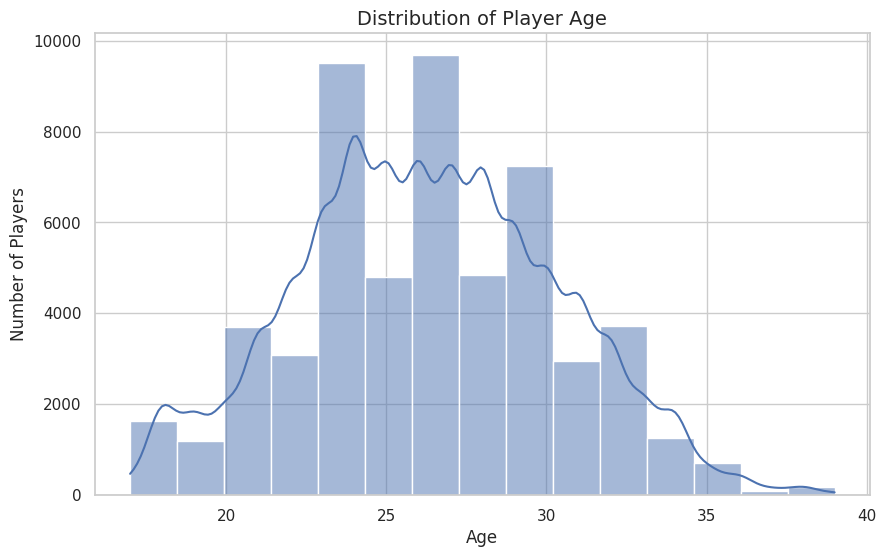

In [13]:
# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="age",
    bins=15,
    kde=True
)

plt.title("Distribution of Player Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Number of Players")

plt.show()

### Insights

- Shows how player ages are distributed across the tournament.
- Identifies the most common age group.
- Highlights whether the tournament is dominated by younger or experienced players.

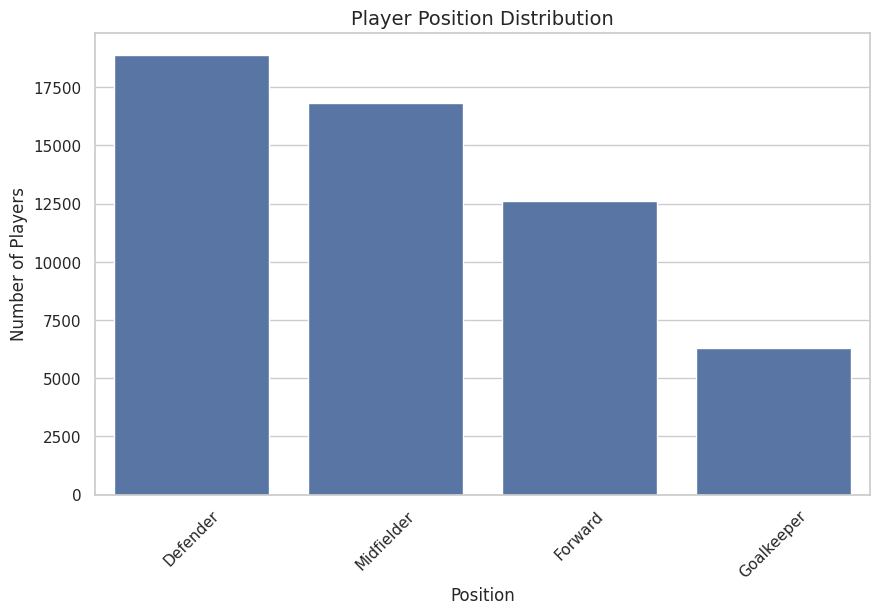

In [14]:
# ============================================================
# Position Distribution
# ============================================================

plt.figure(figsize=(10,6))

position_counts = df["position"].value_counts()

sns.barplot(
    x=position_counts.index,
    y=position_counts.values
)

plt.title("Player Position Distribution", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)

plt.show()

### Insights

- Displays the number of players in each playing position.
- Helps understand the positional composition of the tournament.
- Useful for comparing performance metrics later across positions.

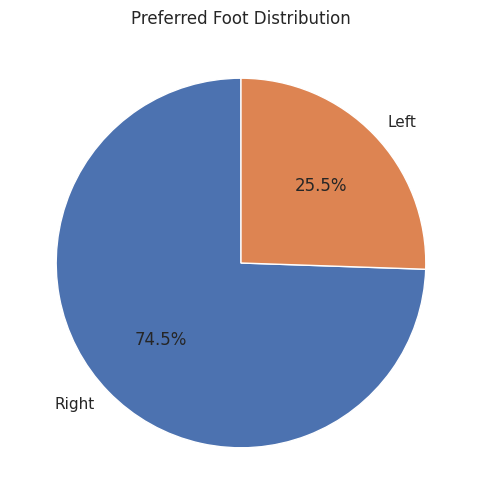

In [15]:
# ============================================================
# Preferred Foot Distribution
# ============================================================

plt.figure(figsize=(6,6))

df["preferred_foot"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Preferred Foot Distribution")

plt.show()

### Insights

- Shows the proportion of left-footed and right-footed players.
- Helps understand player dominance across the tournament.

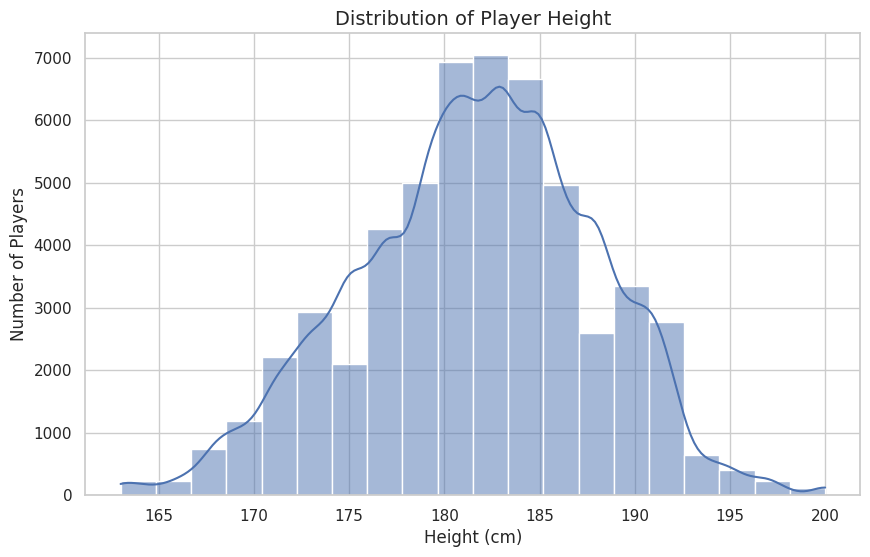

In [16]:
# ============================================================
# Height Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="height_cm",
    bins=20,
    kde=True
)

plt.title("Distribution of Player Height", fontsize=14)
plt.xlabel("Height (cm)")
plt.ylabel("Number of Players")

plt.show()

### Insights

- Shows the distribution of player heights in the tournament.
- Helps identify the most common height range.
- Useful for comparing physical characteristics across different positions later in the analysis.

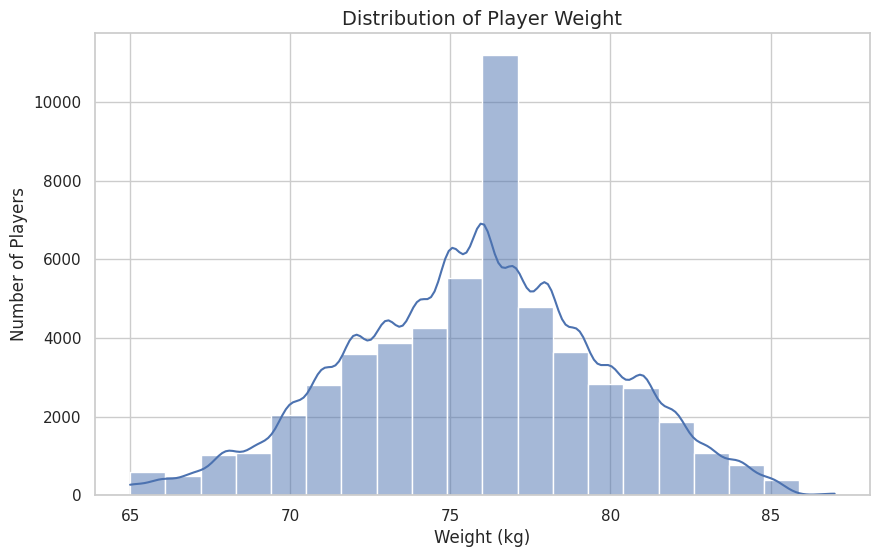

In [17]:
# ============================================================
# Weight Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="weight_kg",
    bins=20,
    kde=True
)

plt.title("Distribution of Player Weight", fontsize=14)
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Players")

plt.show()

### Insights

- Illustrates the distribution of player weights.
- Helps identify the most common weight range.
- Provides context for future analyses involving physical performance.

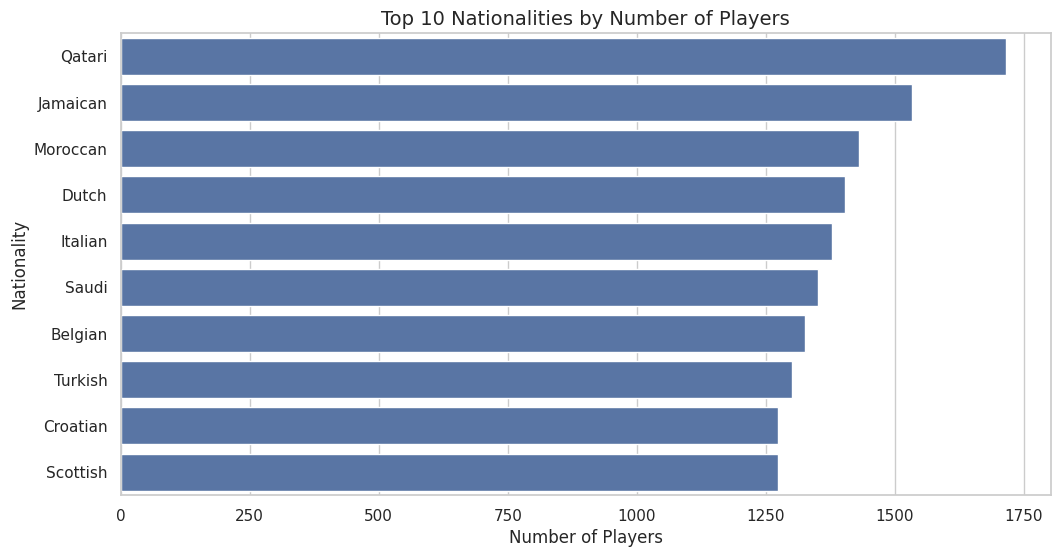

In [18]:
# ============================================================
# Top 10 Nationalities
# ============================================================

top_nationalities = df["nationality"].value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_nationalities.values,
    y=top_nationalities.index
)

plt.title("Top 10 Nationalities by Number of Players", fontsize=14)
plt.xlabel("Number of Players")
plt.ylabel("Nationality")

plt.show()

### Insights

- Identifies the countries contributing the largest number of players.
- Highlights nations with the strongest representation in the tournament.
- Provides context for later comparisons between countries and player performance.

## Summary

The player demographic analysis provides an overview of the tournament participants.

Key observations include:

- The age distribution reveals the balance between young and experienced players.
- Height and weight distributions indicate the overall physical profile of participants.
- Position analysis shows how players are distributed across different roles on the field.
- Preferred foot distribution highlights the dominance of right-footed players.
- Nationality distribution identifies the countries with the highest player representation.

These demographic characteristics establish the foundation for understanding performance differences explored in the following sections.

# Match Analysis

This section explores match-related variables to understand the overall characteristics of the tournament.

The analysis focuses on:

- Match Results
- Tournament Stages
- Goals Scored
- Goals Conceded
- Minutes Played

These insights provide context before evaluating individual player performance.

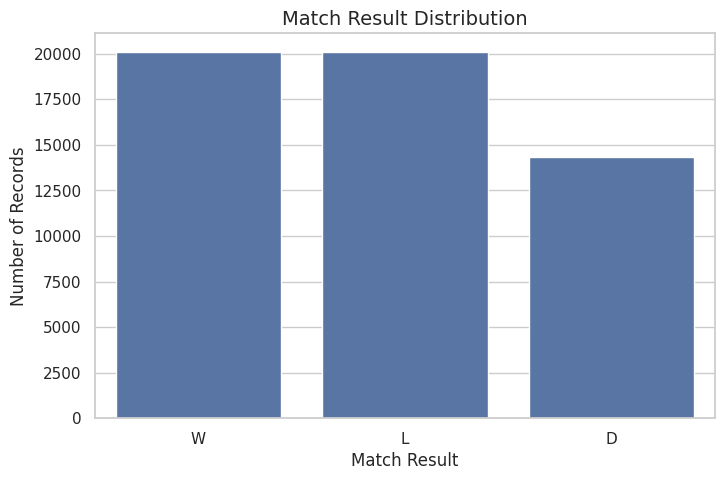

In [19]:
# ============================================================
# Match Result Distribution
# ============================================================

plt.figure(figsize=(8, 5))

match_result = df["match_result"].value_counts()

sns.barplot(
    x=match_result.index,
    y=match_result.values
)

plt.title("Match Result Distribution", fontsize=14)
plt.xlabel("Match Result")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Displays the frequency of wins, losses, and draws.
- Provides an overview of match outcomes across the tournament.
- Helps understand the balance between different match results.

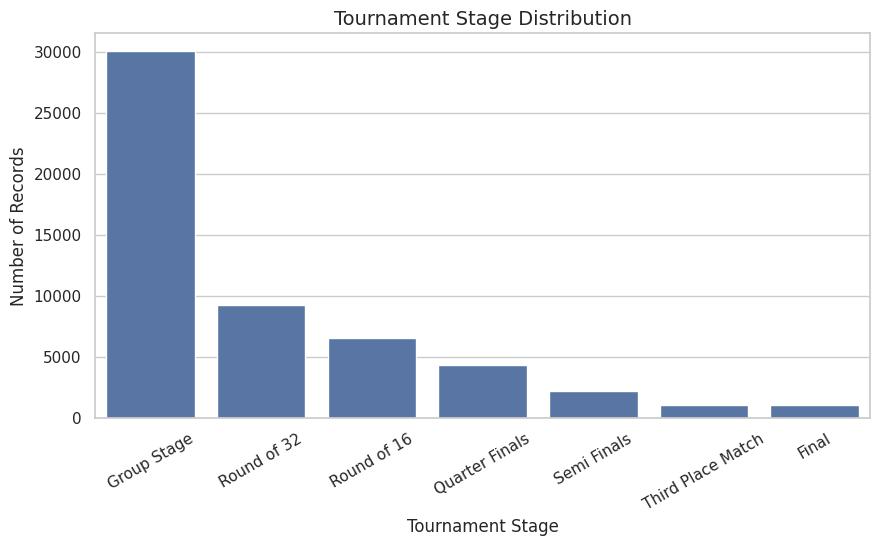

In [20]:
# ============================================================
# Tournament Stage Distribution
# ============================================================

plt.figure(figsize=(10, 5))

stage = df["tournament_stage"].value_counts()

sns.barplot(
    x=stage.index,
    y=stage.values
)

plt.title("Tournament Stage Distribution", fontsize=14)
plt.xlabel("Tournament Stage")
plt.ylabel("Number of Records")

plt.xticks(rotation=30)

plt.show()

### Insights

- Shows how player records are distributed across tournament stages.
- Indicates which stages contribute the largest share of observations.
- Useful for comparing player performance in different phases later.

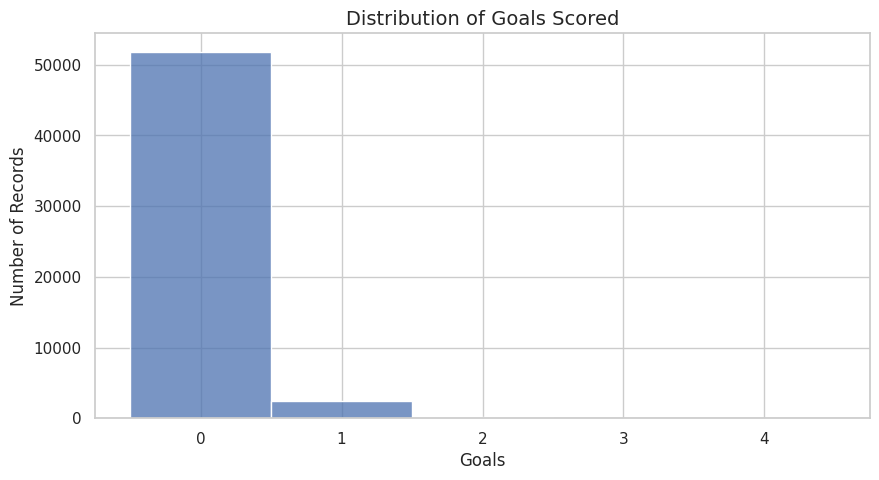

In [21]:
# ============================================================
# Goals Scored Distribution
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="goals",
    bins=10,
    discrete=True
)

plt.title("Distribution of Goals Scored", fontsize=14)
plt.xlabel("Goals")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Illustrates how frequently players score goals.
- Identifies whether goal-scoring is concentrated among a small number of players.
- Highlights the overall scoring pattern in the tournament.

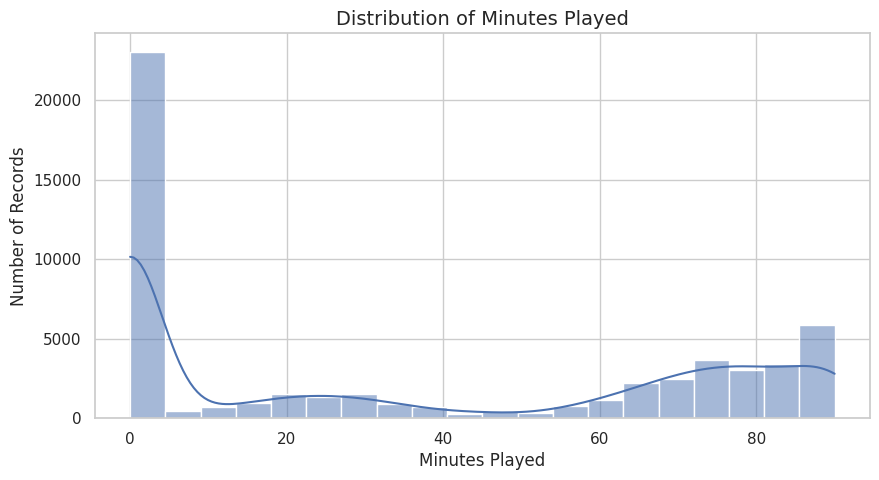

In [22]:
# ============================================================
# Minutes Played Distribution
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="minutes_played",
    bins=20,
    kde=True
)

plt.title("Distribution of Minutes Played", fontsize=14)
plt.xlabel("Minutes Played")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Shows how long players typically remain on the field.
- Identifies common playing-time ranges.
- Provides context for interpreting player performance statistics.

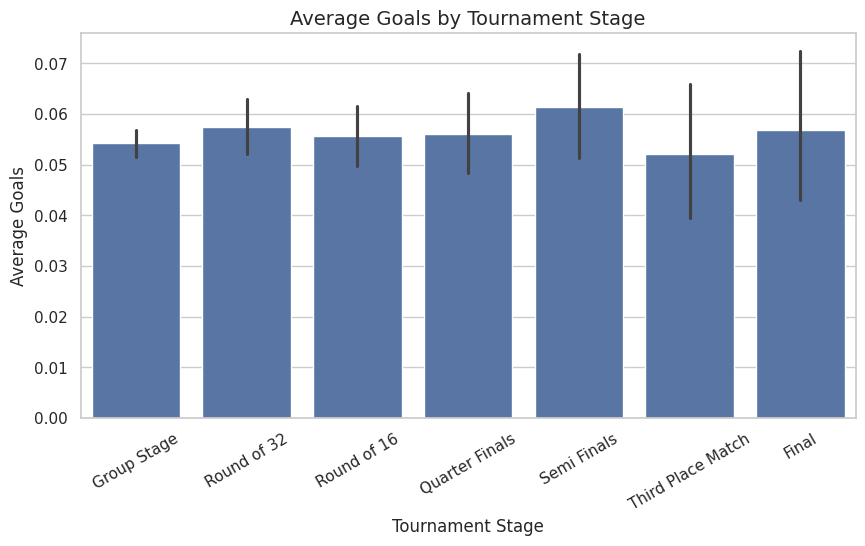

In [23]:
# ============================================================
# Average Goals by Tournament Stage
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="tournament_stage",
    y="goals",
    estimator="mean"
)

plt.title("Average Goals by Tournament Stage", fontsize=14)
plt.xlabel("Tournament Stage")
plt.ylabel("Average Goals")

plt.xticks(rotation=30)

plt.show()

### Insights

- Compares the average number of goals scored across tournament stages.
- Helps identify stages where attacking performance is strongest.
- Provides context for evaluating player performance under varying competition levels.

# Offensive Performance Analysis

Attacking performance is one of the most important aspects of football. This section evaluates how players contribute offensively by analyzing goal scoring, chance creation, shooting efficiency, and expected performance metrics.

The analysis focuses on:

- Goals Scored
- Assists
- Shots
- Shots on Target
- Expected Goals (xG)
- Expected Assists (xA)
- Key Passes

These metrics help identify the tournament's most effective attacking players and provide insights into offensive consistency and efficiency.

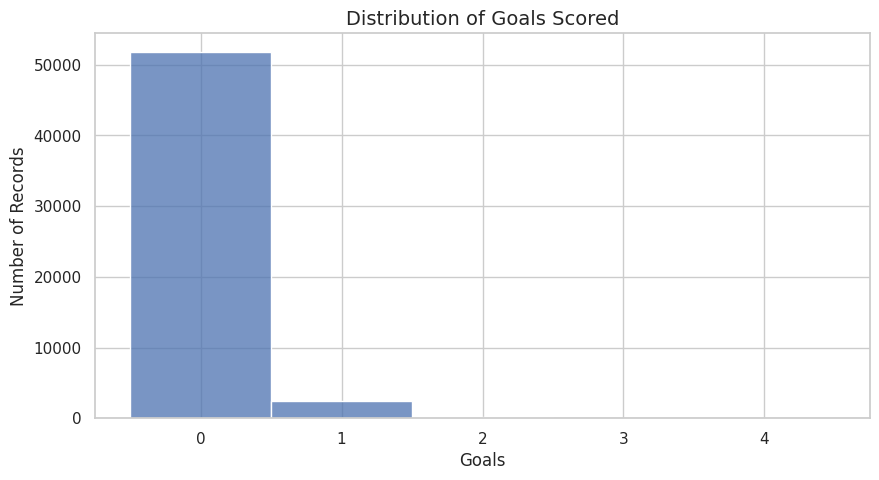

In [24]:
# ============================================================
# Goals Distribution
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="goals",
    bins=10,
    discrete=True
)

plt.title("Distribution of Goals Scored", fontsize=14)
plt.xlabel("Goals")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Most player appearances are associated with a low number of goals.
- High goal-scoring performances are relatively uncommon.
- The distribution highlights the difference between regular contributors and exceptional attacking performances.

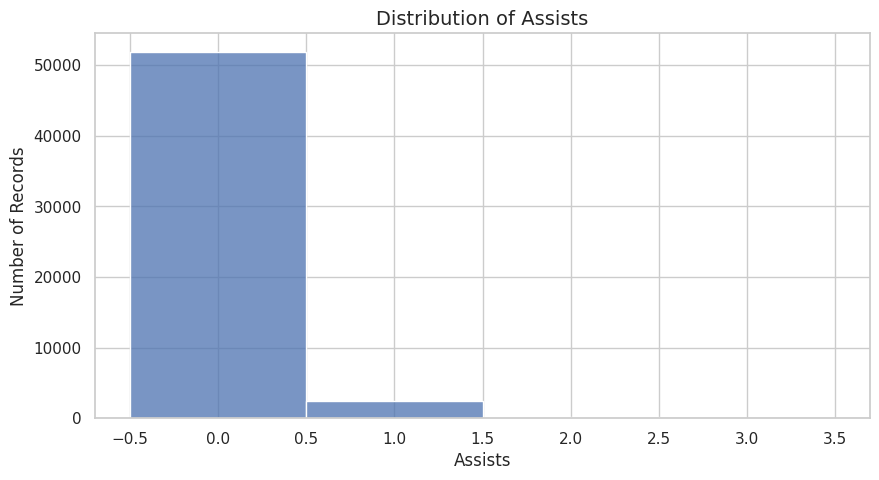

In [25]:
# ============================================================
# Assists Distribution
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="assists",
    bins=8,
    discrete=True
)

plt.title("Distribution of Assists", fontsize=14)
plt.xlabel("Assists")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Most players register few or no assists in a match.
- A small number of performances involve multiple assists.
- The distribution highlights the rarity of high-level playmaking performances.

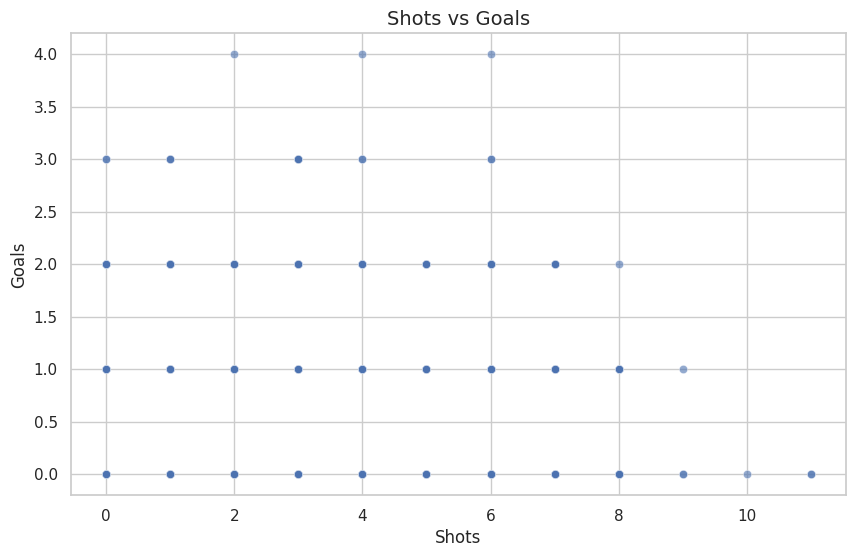

In [26]:
# ============================================================
# Shots vs Goals
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="shots",
    y="goals",
    alpha=0.6
)

plt.title("Shots vs Goals", fontsize=14)
plt.xlabel("Shots")
plt.ylabel("Goals")

plt.show()

### Insights

- Players with more shots generally have a greater chance of scoring.
- The relationship is positive but not perfectly linear, indicating differences in finishing efficiency.
- Some players convert opportunities more effectively than others.

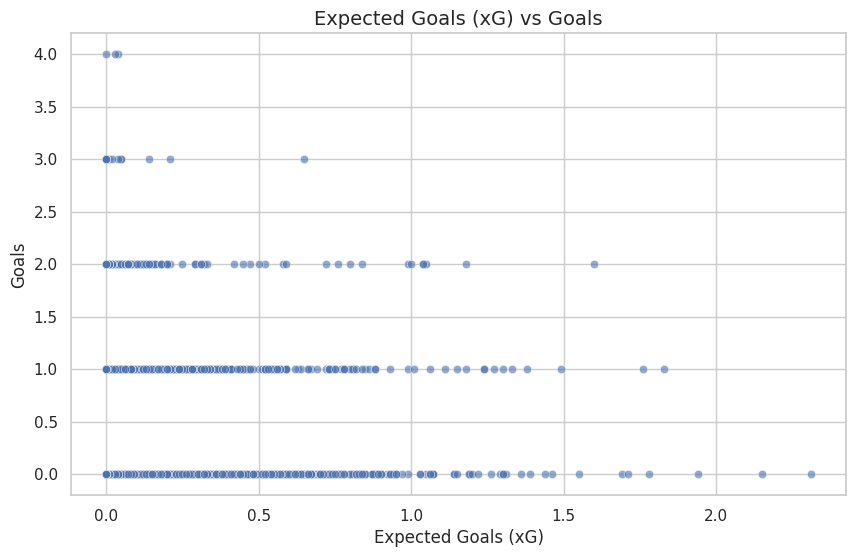

In [27]:
# ============================================================
# Expected Goals vs Actual Goals
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="expected_goals_xg",
    y="goals",
    alpha=0.6
)

plt.title("Expected Goals (xG) vs Goals", fontsize=14)
plt.xlabel("Expected Goals (xG)")
plt.ylabel("Goals")

plt.show()

### Insights

- Expected Goals (xG) estimates the quality of scoring opportunities.
- Players performing above the general trend may be finishing chances more efficiently.
- Comparing xG with actual goals helps identify clinical finishers and underperformers.

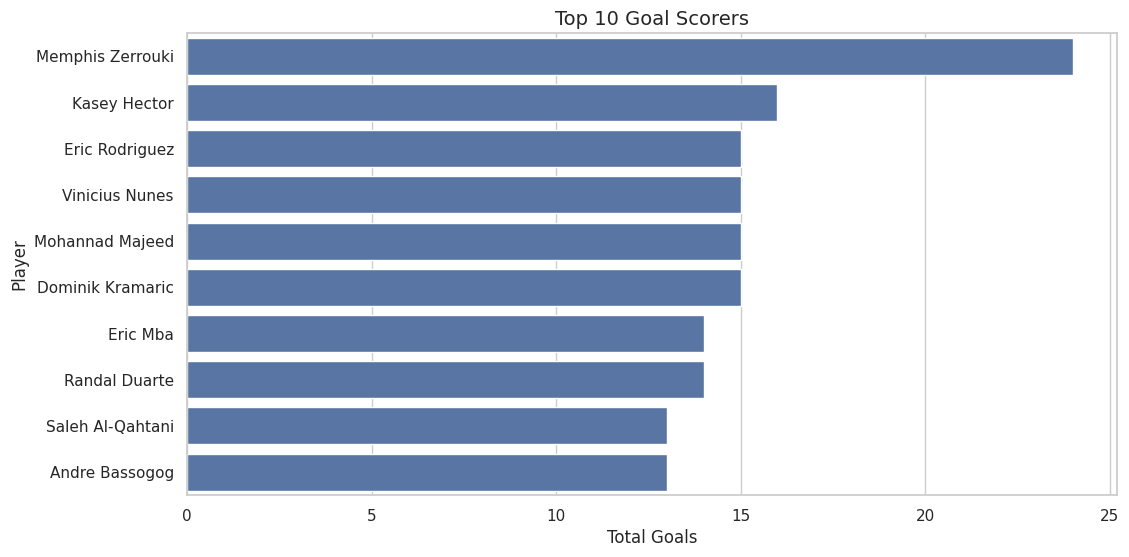

In [28]:
# ============================================================
# Top 10 Goal Scorers
# ============================================================

top_scorers = (
    df.groupby("player_name")["goals"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_scorers.values,
    y=top_scorers.index
)

plt.title("Top 10 Goal Scorers", fontsize=14)
plt.xlabel("Total Goals")
plt.ylabel("Player")

plt.show()

### Insights

- Highlights the tournament's highest-scoring players.
- Identifies consistent attacking contributors.
- Useful for evaluating offensive impact and player effectiveness.

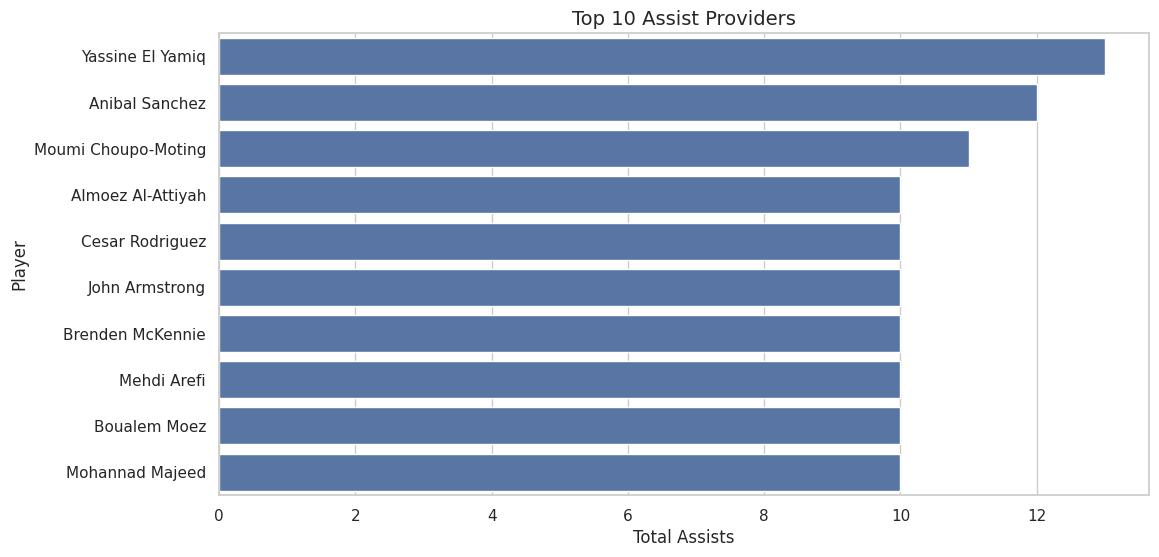

In [29]:
# ============================================================
# Top 10 Assist Providers
# ============================================================

top_assists = (
    df.groupby("player_name")["assists"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_assists.values,
    y=top_assists.index
)

plt.title("Top 10 Assist Providers", fontsize=14)
plt.xlabel("Total Assists")
plt.ylabel("Player")

plt.show()

### Insights

- Highlights the players contributing the most assists.
- Identifies key playmakers responsible for creating scoring opportunities.
- Complements goal-scoring analysis by evaluating creative contributions.

## Summary

The offensive analysis demonstrates how players contribute through scoring, creativity, and chance generation.

Key observations include:

- Goal-scoring is concentrated among a relatively small group of players.
- Assists are similarly distributed, with a few players consistently creating opportunities.
- Expected Goals (xG) provides additional insight into finishing efficiency.
- Combining goals, assists, and shooting metrics offers a more complete assessment of attacking performance.

# Passing Performance Analysis

Passing is a fundamental aspect of football that influences possession, chance creation, and overall team performance.

In this section, we analyze:

- Total Passes
- Pass Accuracy
- Key Passes
- Successful Crosses
- Long Balls
- Through Balls

These metrics help identify the tournament's most effective playmakers and ball distributors.

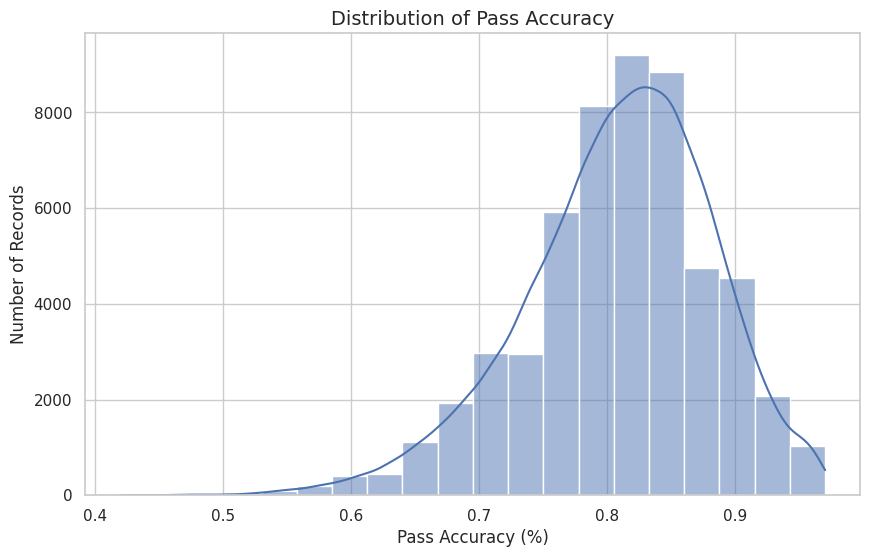

In [30]:
# ============================================================
# Pass Accuracy Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="pass_accuracy",
    bins=20,
    kde=True
)

plt.title("Distribution of Pass Accuracy", fontsize=14)
plt.xlabel("Pass Accuracy (%)")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Most players maintain a high passing accuracy.
- The distribution indicates the overall passing quality across the tournament.
- Players with exceptionally high accuracy are likely to play key roles in ball retention.

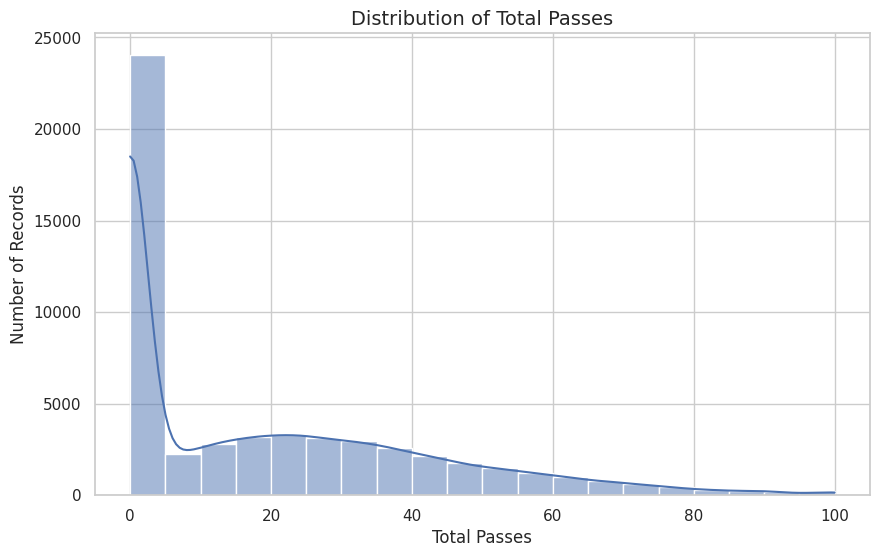

In [31]:
# ============================================================
# Total Passes Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="total_passes",
    bins=20,
    kde=True
)

plt.title("Distribution of Total Passes", fontsize=14)
plt.xlabel("Total Passes")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Shows how actively players participate in ball circulation.
- Higher passing volumes often indicate greater involvement in possession.
- The distribution highlights differences in playing styles across positions.

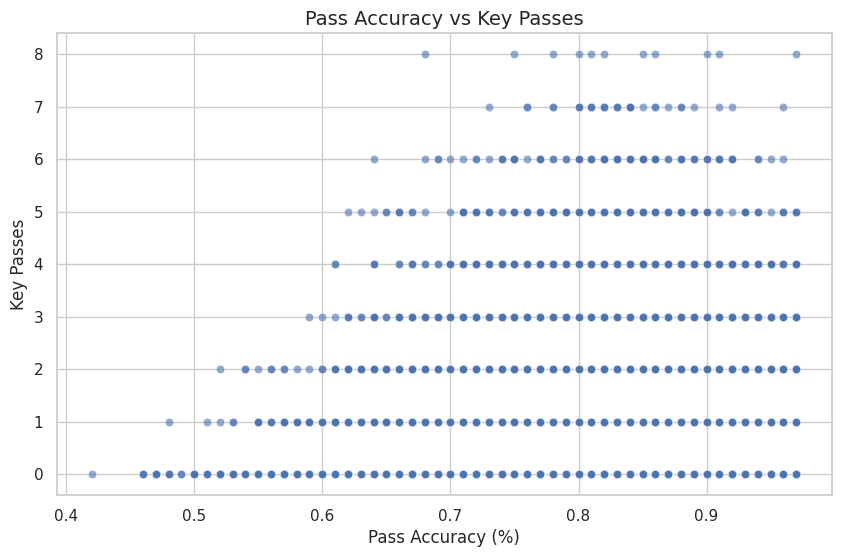

In [32]:
# ============================================================
# Pass Accuracy vs Key Passes
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="pass_accuracy",
    y="key_passes",
    alpha=0.6
)

plt.title("Pass Accuracy vs Key Passes", fontsize=14)
plt.xlabel("Pass Accuracy (%)")
plt.ylabel("Key Passes")

plt.show()

### Insights

- Examines the relationship between passing efficiency and chance creation.
- High pass accuracy does not always correspond to a higher number of key passes.
- Creative players often balance accuracy with risk-taking.

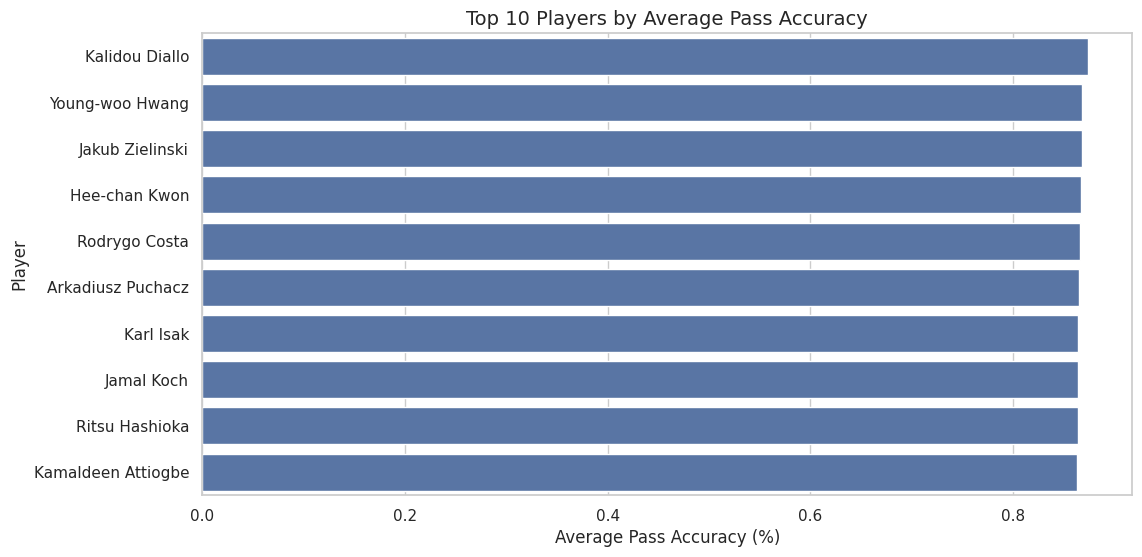

In [33]:
# ============================================================
# Top 10 Players by Pass Accuracy
# ============================================================

top_accuracy = (
    df.groupby("player_name")["pass_accuracy"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_accuracy.values,
    y=top_accuracy.index
)

plt.title("Top 10 Players by Average Pass Accuracy", fontsize=14)
plt.xlabel("Average Pass Accuracy (%)")
plt.ylabel("Player")

plt.show()

### Insights

- Highlights players with the highest average passing accuracy.
- Identifies reliable ball distributors.
- Useful for evaluating midfield control and possession-oriented players.

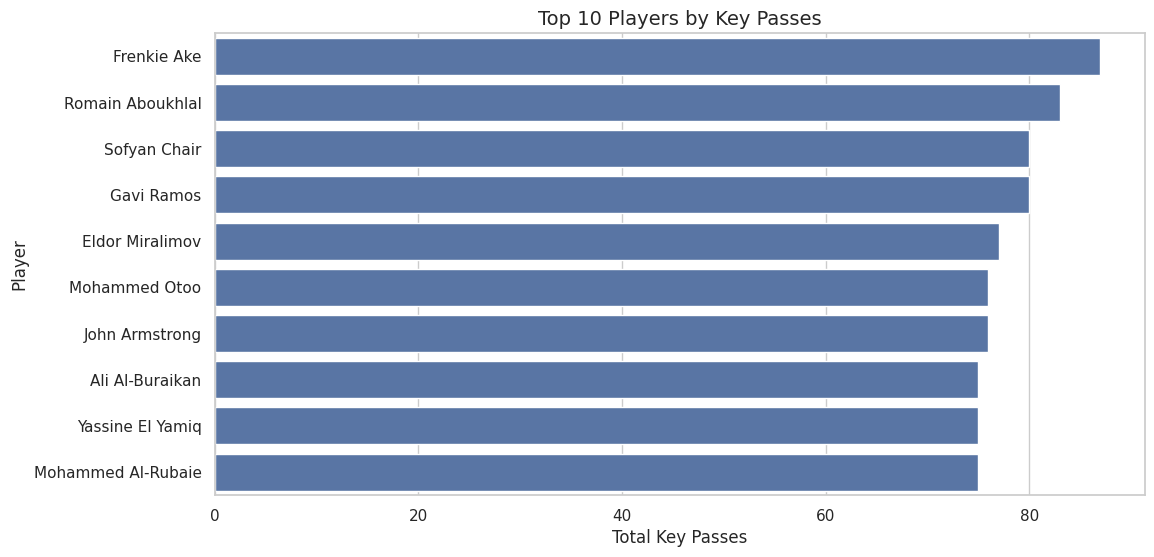

In [34]:
# ============================================================
# Top 10 Players by Key Passes
# ============================================================

top_key_passes = (
    df.groupby("player_name")["key_passes"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_key_passes.values,
    y=top_key_passes.index
)

plt.title("Top 10 Players by Key Passes", fontsize=14)
plt.xlabel("Total Key Passes")
plt.ylabel("Player")

plt.show()

### Insights

- Identifies the tournament's most creative players.
- Key passes represent passes leading directly to a shot.
- These players contribute significantly to attacking opportunities.

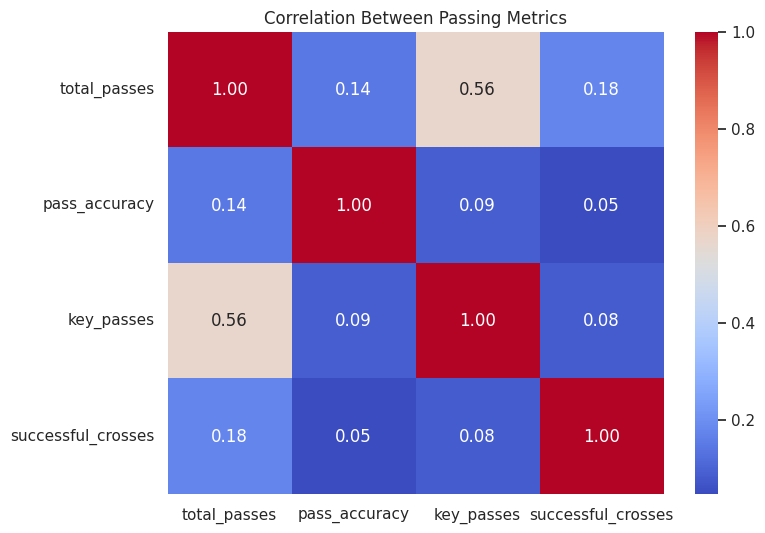

In [35]:
# ============================================================
# Correlation of Passing Metrics
# ============================================================

passing_metrics = df[
    [
        "total_passes",
        "pass_accuracy",
        "key_passes",
        "successful_crosses"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    passing_metrics.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Passing Metrics")

plt.show()

## Summary

The passing analysis provides valuable insights into how players contribute to maintaining possession and creating attacking opportunities.

### Key Findings

- Most players demonstrate consistently high passing accuracy, reflecting the importance of ball retention in modern football.
- Players with a higher number of total passes tend to be more involved in controlling the game's tempo and possession.
- Key passes and successful crosses are strong indicators of a player's creativity and ability to generate goal-scoring opportunities.
- The correlation analysis highlights the relationships between different passing metrics, helping identify which attributes are most closely associated with effective playmaking.

Overall, passing metrics complement offensive statistics by revealing players who influence the game through distribution, vision, and chance creation rather than goal scoring alone.

# Defensive Performance Analysis

Defensive contributions are equally important in determining a player's overall impact on the game. While goals and assists often receive the most attention, successful defending plays a crucial role in preventing opposition attacks and maintaining team stability.

In this section, we analyze:

- Tackles
- Interceptions
- Blocks
- Recoveries
- Defensive Actions
- Defensive Contribution Score

These metrics help identify players who consistently contribute to their team's defensive performance.

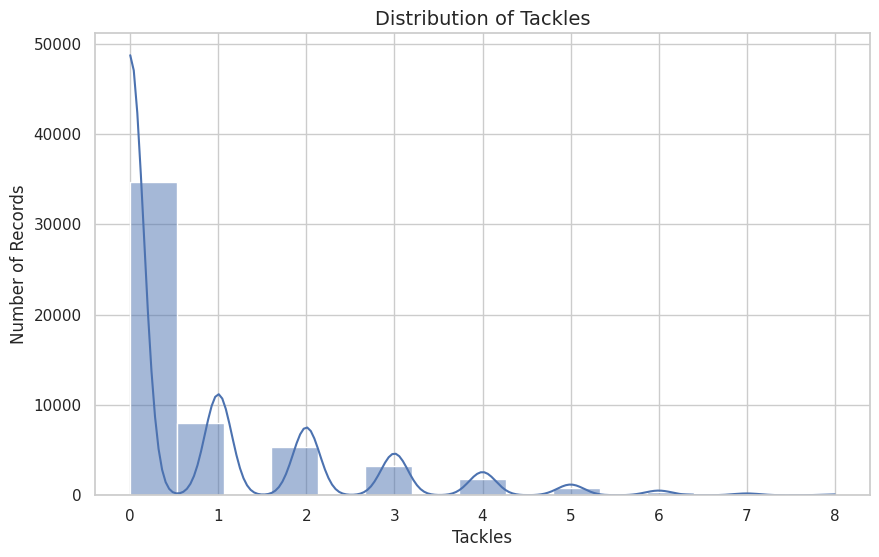

In [36]:
# ============================================================
# Tackles Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="tackles",
    bins=15,
    kde=True
)

plt.title("Distribution of Tackles", fontsize=14)
plt.xlabel("Tackles")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Shows how frequently players make tackles during matches.
- Most players record a relatively small number of tackles per match.
- Higher tackle counts generally indicate greater defensive involvement.

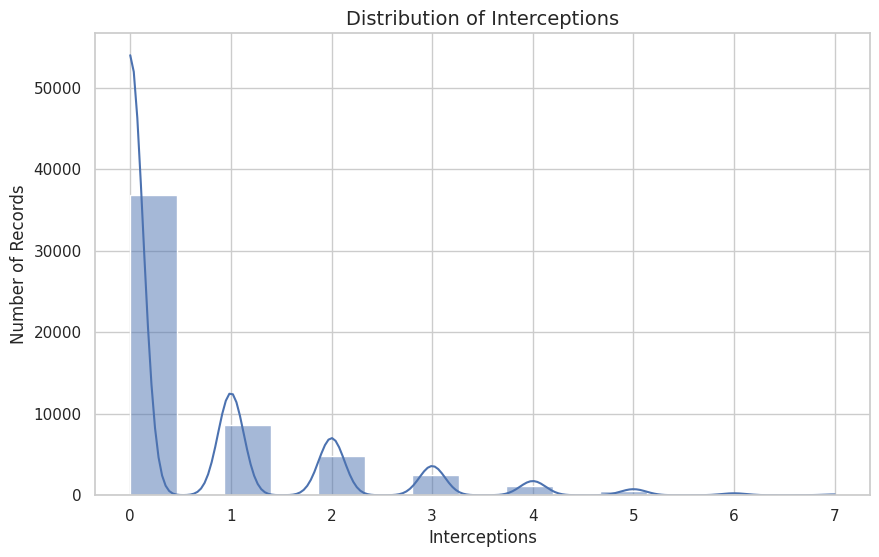

In [37]:
# ============================================================
# Interceptions Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="interceptions",
    bins=15,
    kde=True
)

plt.title("Distribution of Interceptions", fontsize=14)
plt.xlabel("Interceptions")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Interceptions reflect a player's ability to anticipate opposition passes.
- Most players record only a few interceptions per match.
- Players with higher interception counts often demonstrate strong positional awareness.

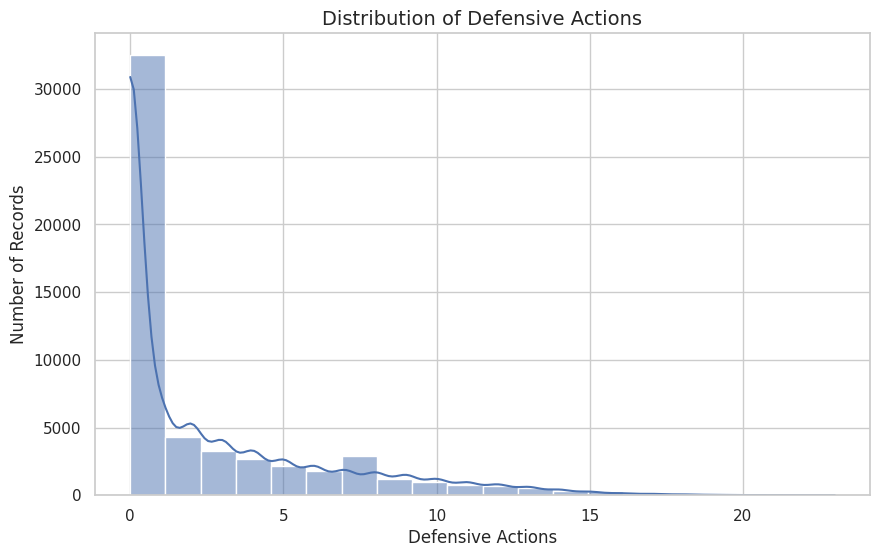

In [38]:
# ============================================================
# Defensive Actions Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="defensive_actions",
    bins=20,
    kde=True
)

plt.title("Distribution of Defensive Actions", fontsize=14)
plt.xlabel("Defensive Actions")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Defensive actions provide a comprehensive measure of a player's defensive involvement.
- Higher values indicate greater participation in stopping opposition attacks.
- This metric combines multiple defensive contributions into a single measure.

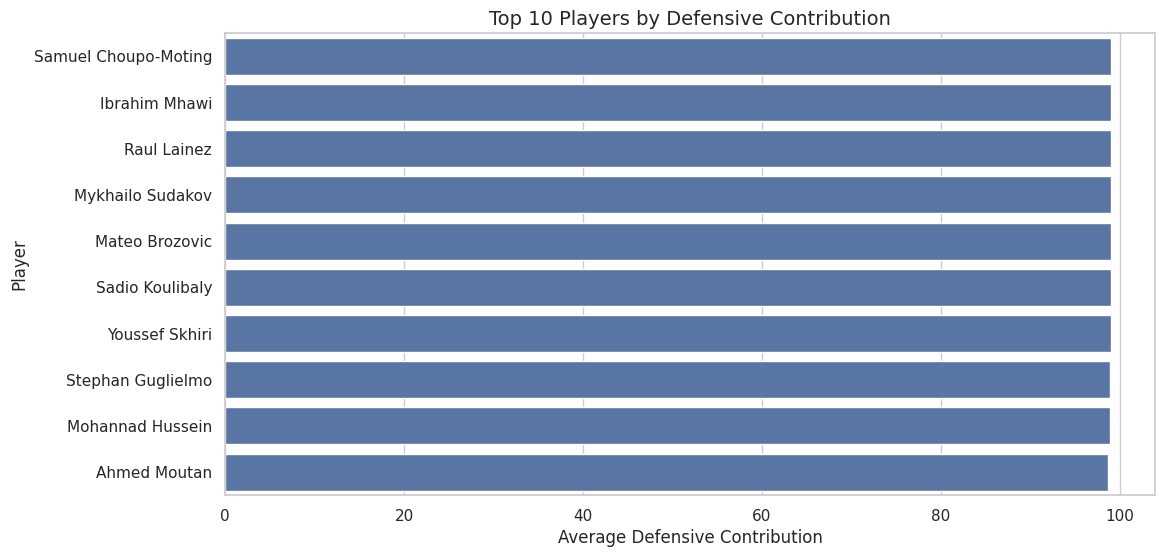

In [39]:
# ============================================================
# Top 10 Players by Defensive Contribution
# ============================================================

top_defenders = (
    df.groupby("player_name")["defensive_contribution"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_defenders.values,
    y=top_defenders.index
)

plt.title("Top 10 Players by Defensive Contribution", fontsize=14)
plt.xlabel("Average Defensive Contribution")
plt.ylabel("Player")

plt.show()

### Insights

- Highlights players with the strongest overall defensive impact.
- Defensive contribution combines multiple defensive metrics into a single performance score.
- These players consistently influence matches through defensive excellence.

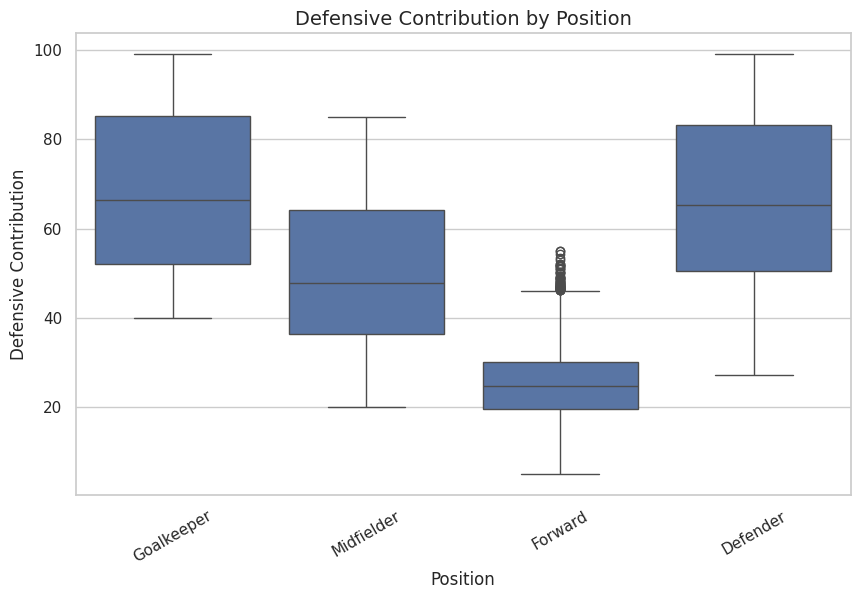

In [40]:
# ============================================================
# Defensive Contribution by Position
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="position",
    y="defensive_contribution"
)

plt.title("Defensive Contribution by Position", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Defensive Contribution")

plt.xticks(rotation=30)

plt.show()

### Insights

- Compares defensive contribution across different playing positions.
- Defensive positions are expected to show higher contribution scores.
- The spread of values highlights consistency and variation within each position.

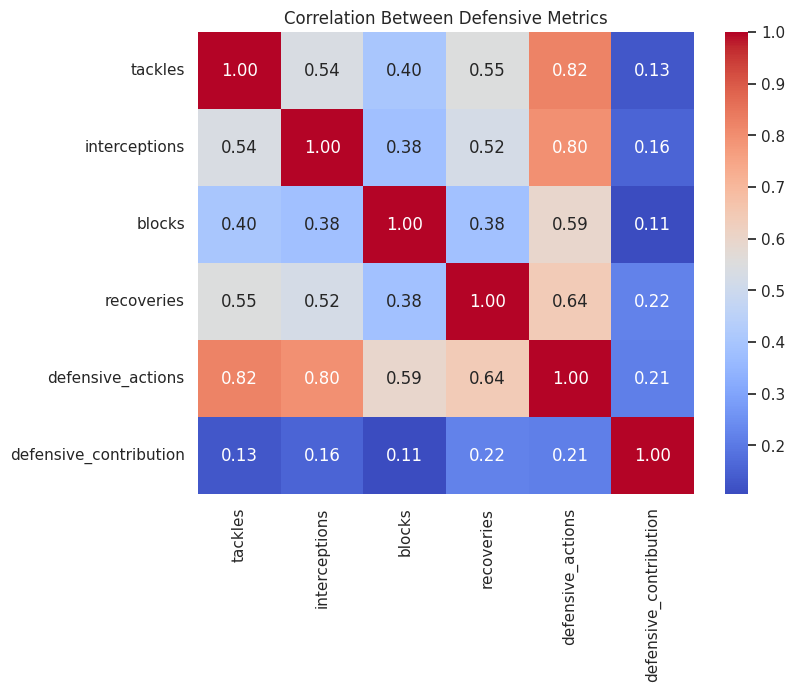

In [41]:
# ============================================================
# Correlation of Defensive Metrics
# ============================================================

defensive_metrics = df[
    [
        "tackles",
        "interceptions",
        "blocks",
        "recoveries",
        "defensive_actions",
        "defensive_contribution"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    defensive_metrics.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Defensive Metrics")

plt.show()

## Summary

The defensive analysis demonstrates how players contribute by preventing opposition attacks and protecting their team's defensive structure.

### Key Findings

- Tackles, interceptions, and recoveries provide different perspectives on defensive performance.
- Defensive contribution scores offer a comprehensive assessment of a player's defensive effectiveness.
- Comparing defensive metrics across positions highlights the specialized responsibilities of different roles.
- Correlation analysis helps identify which defensive statistics are most closely related to overall defensive performance.

Together, these metrics provide a well-rounded evaluation of defensive impact beyond traditional statistics.

# Performance Metrics Analysis

Individual statistics such as goals, assists, and tackles provide valuable information, but they only capture specific aspects of a player's contribution.

This section focuses on comprehensive performance indicators that summarize overall effectiveness during the tournament.

The analysis includes:

- Performance Score
- Offensive Contribution
- Defensive Contribution
- Creativity Score
- Stamina Score
- Pressure Resistance
- Clutch Performance Score

These metrics provide a holistic view of player performance and help identify consistently high-performing players.

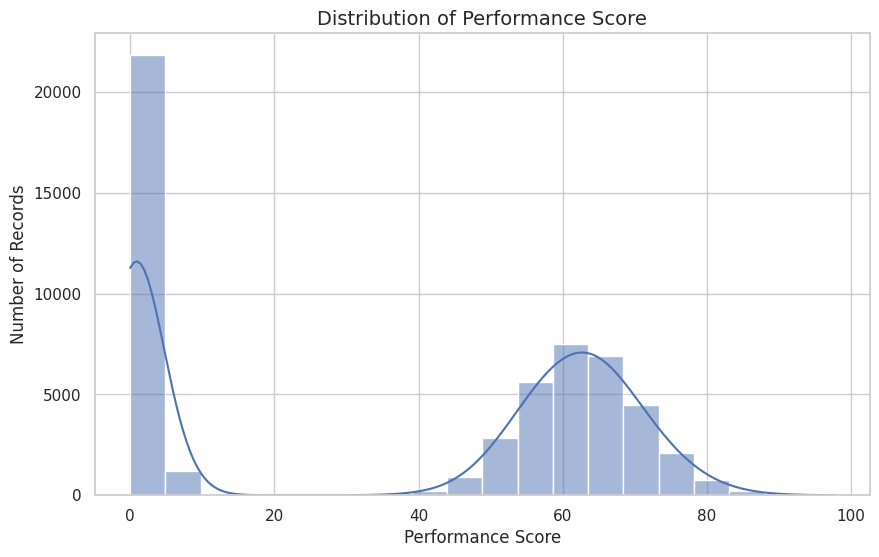

In [42]:
# ============================================================
# Performance Score Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="performance_score",
    bins=20,
    kde=True
)

plt.title("Distribution of Performance Score", fontsize=14)
plt.xlabel("Performance Score")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Shows the overall distribution of player performance scores.
- Helps identify the most common performance range.
- Highlights whether elite performances are common or relatively rare.

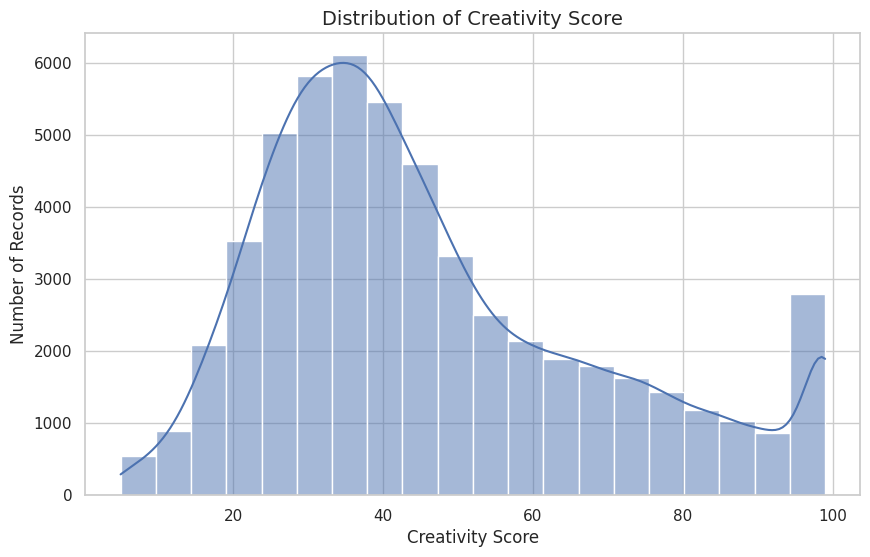

In [43]:
# ============================================================
# Creativity Score Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="creativity_score",
    bins=20,
    kde=True
)

plt.title("Distribution of Creativity Score", fontsize=14)
plt.xlabel("Creativity Score")
plt.ylabel("Number of Records")

plt.show()

### Insights

- Creativity Score reflects a player's ability to generate attacking opportunities.
- The distribution highlights the variation in creative influence across players.
- Higher values indicate stronger playmaking ability.

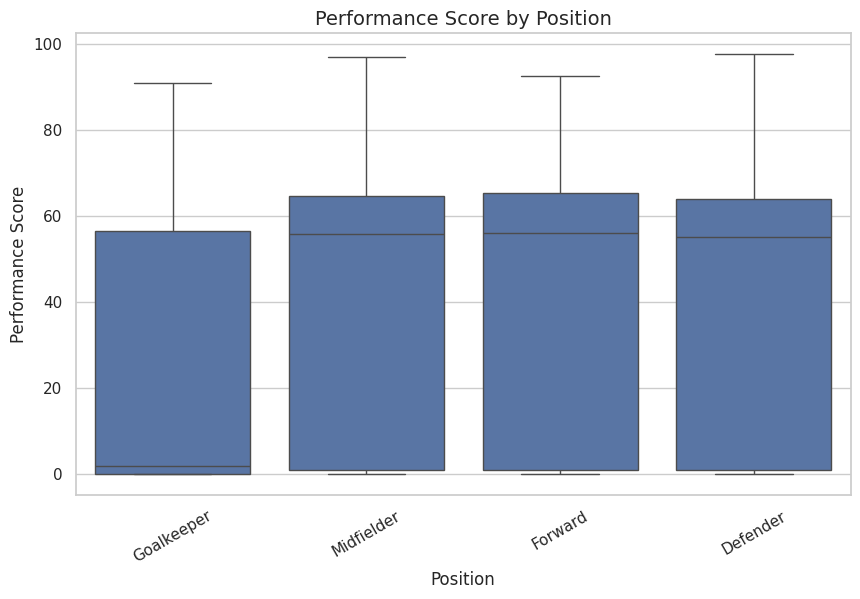

In [44]:
# ============================================================
# Performance Score by Position
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="position",
    y="performance_score"
)

plt.title("Performance Score by Position", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Performance Score")

plt.xticks(rotation=30)

plt.show()

### Insights

- Compares overall performance across different playing positions.
- Reveals positional differences in performance consistency.
- Boxplots help identify variability and outliers within each position.

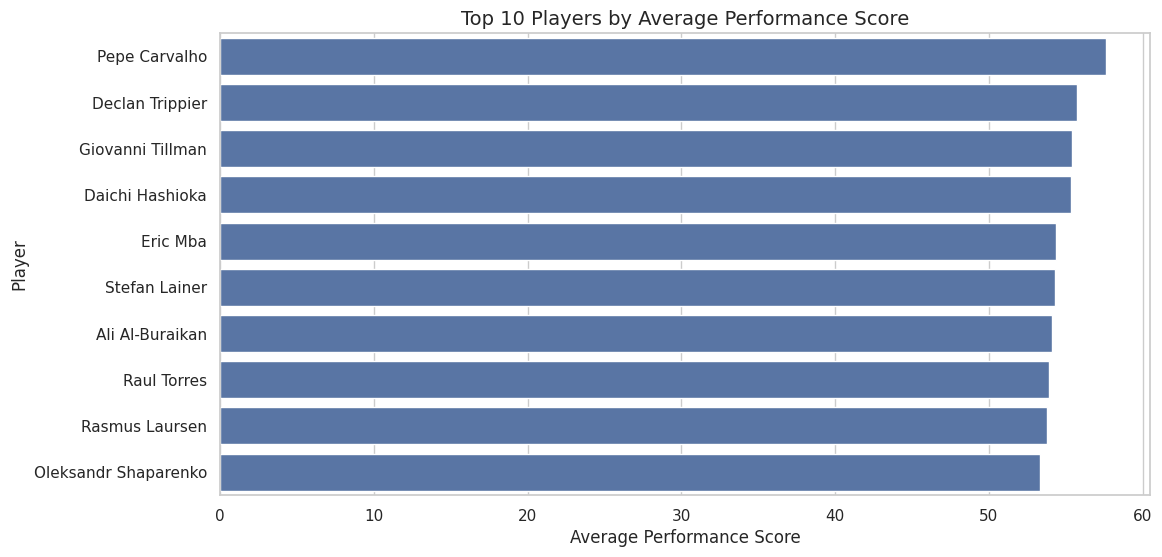

In [45]:
# ============================================================
# Top 10 Players by Performance Score
# ============================================================

top_players = (
    df.groupby("player_name")["performance_score"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_players.values,
    y=top_players.index
)

plt.title("Top 10 Players by Average Performance Score", fontsize=14)
plt.xlabel("Average Performance Score")
plt.ylabel("Player")

plt.show()

### Insights

- Identifies the tournament's highest-performing players.
- Average scores provide a better measure of consistency than single-match performances.
- Useful for recognizing players who deliver strong performances throughout the tournament.

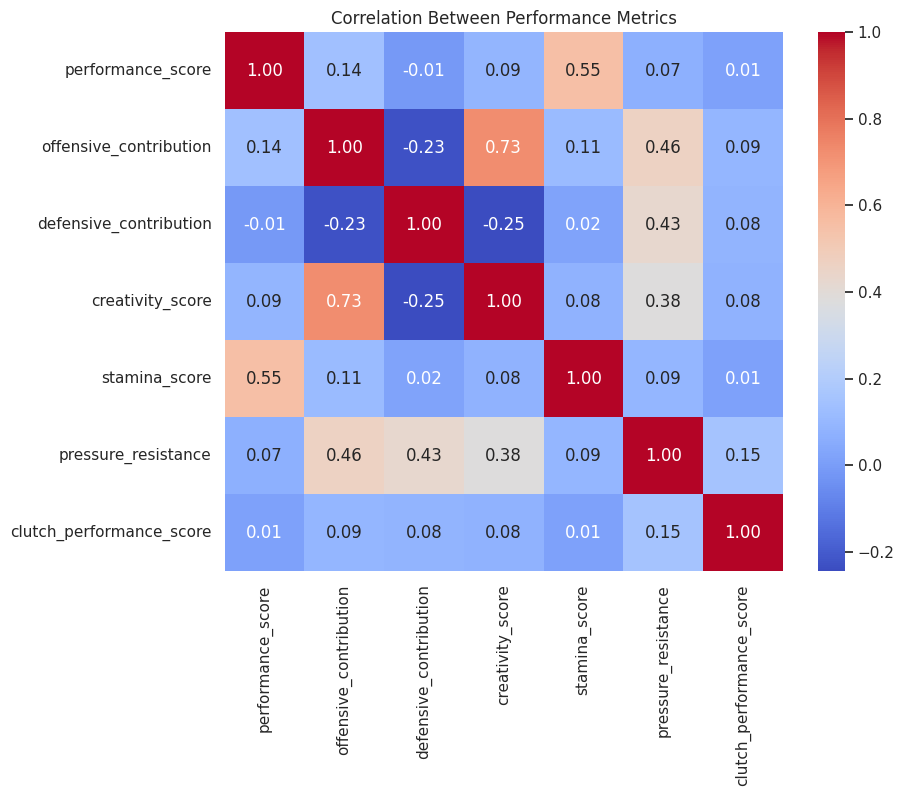

In [46]:
# ============================================================
# Correlation Between Performance Metrics
# ============================================================

performance_metrics = df[
    [
        "performance_score",
        "offensive_contribution",
        "defensive_contribution",
        "creativity_score",
        "stamina_score",
        "pressure_resistance",
        "clutch_performance_score"
    ]
]

plt.figure(figsize=(9,7))

sns.heatmap(
    performance_metrics.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Performance Metrics")

plt.show()

## Summary

The performance metrics analysis provides a comprehensive evaluation of player effectiveness by combining offensive, defensive, physical, and psychological attributes.

### Key Findings

- Performance Score offers an overall assessment of player contribution.
- Creativity and offensive contribution are closely linked to attacking effectiveness.
- Defensive contribution highlights players who consistently impact the game without necessarily scoring goals.
- Correlation analysis reveals how different performance metrics interact to influence overall player ratings.

Together, these metrics provide a balanced framework for evaluating player performance beyond traditional football statistics.

# Team Performance Analysis

Football is ultimately a team sport, and while individual performances are important, team-level analysis provides valuable insights into overall tactical effectiveness and consistency.

This section evaluates team performance by comparing offensive output, defensive strength, creativity, and overall performance metrics.

The analysis includes:

- Team Representation
- Average Performance Score
- Goals Scored
- Offensive Contribution
- Defensive Contribution
- Creativity Score

These insights help identify the strongest performing teams in the tournament.

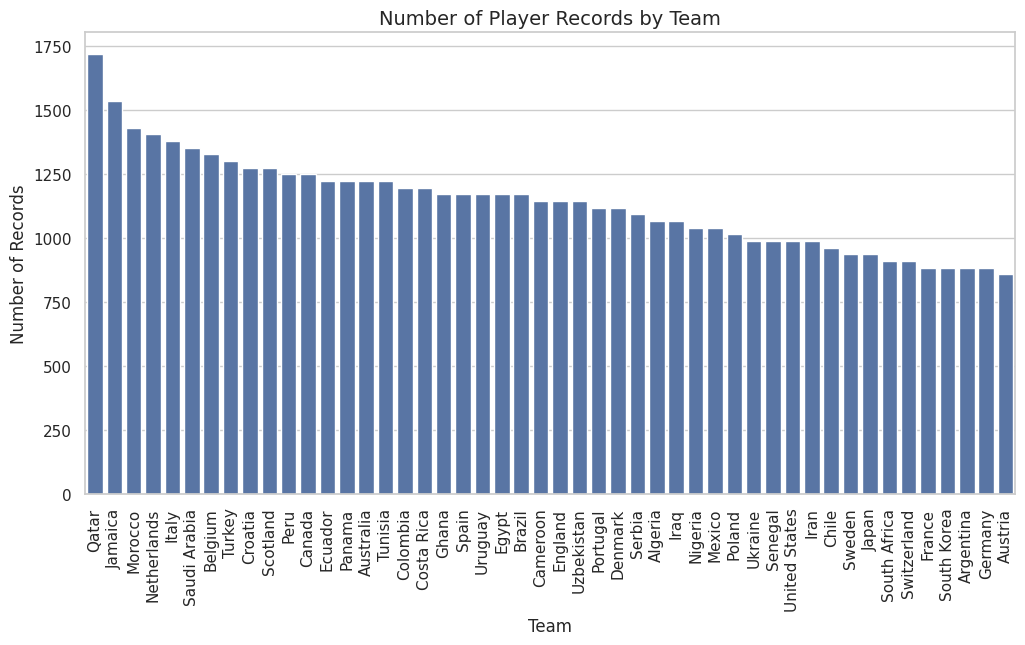

In [47]:
# ============================================================
# Team Representation
# ============================================================

team_count = df["team"].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=team_count.index,
    y=team_count.values
)

plt.title("Number of Player Records by Team", fontsize=14)
plt.xlabel("Team")
plt.ylabel("Number of Records")

plt.xticks(rotation=90)

plt.show()

### Insights

- Shows the number of player-match records available for each team.
- Provides an overview of team representation within the dataset.
- Useful for understanding the distribution of observations before comparing team performance.

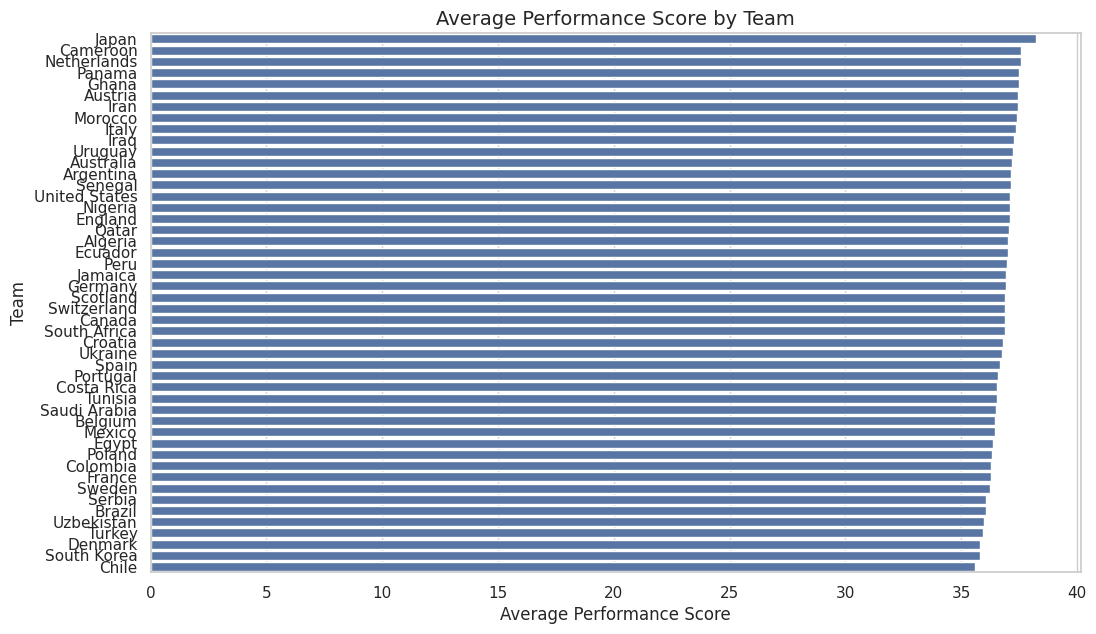

In [48]:
# ============================================================
# Average Team Performance Score
# ============================================================

team_perf = (
    df.groupby("team")["performance_score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=team_perf.values,
    y=team_perf.index
)

plt.title("Average Performance Score by Team", fontsize=14)
plt.xlabel("Average Performance Score")
plt.ylabel("Team")

plt.show()

### Insights

- Compares the average overall performance score across all teams.
- Highlights teams with consistently strong player performances.
- Provides a high-level comparison of team quality.

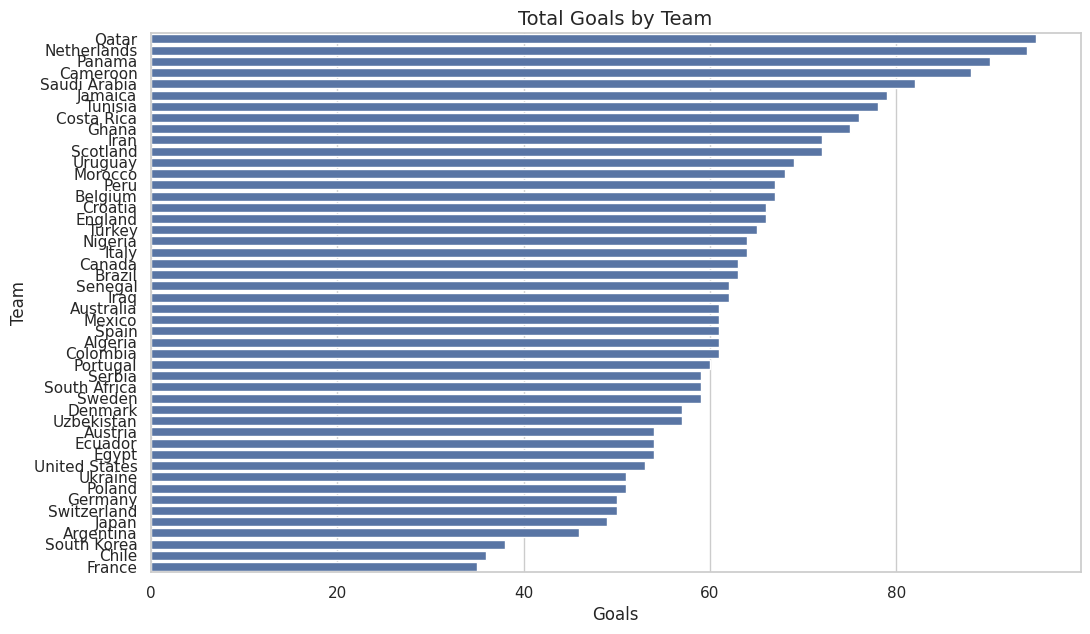

In [49]:
# ============================================================
# Goals by Team
# ============================================================

team_goals = (
    df.groupby("team")["goals"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=team_goals.values,
    y=team_goals.index
)

plt.title("Total Goals by Team", fontsize=14)
plt.xlabel("Goals")
plt.ylabel("Team")

plt.show()

### Insights

- Shows which teams contributed the highest number of goals.
- Highlights the strongest attacking teams in the tournament.
- Useful for comparing offensive productivity.

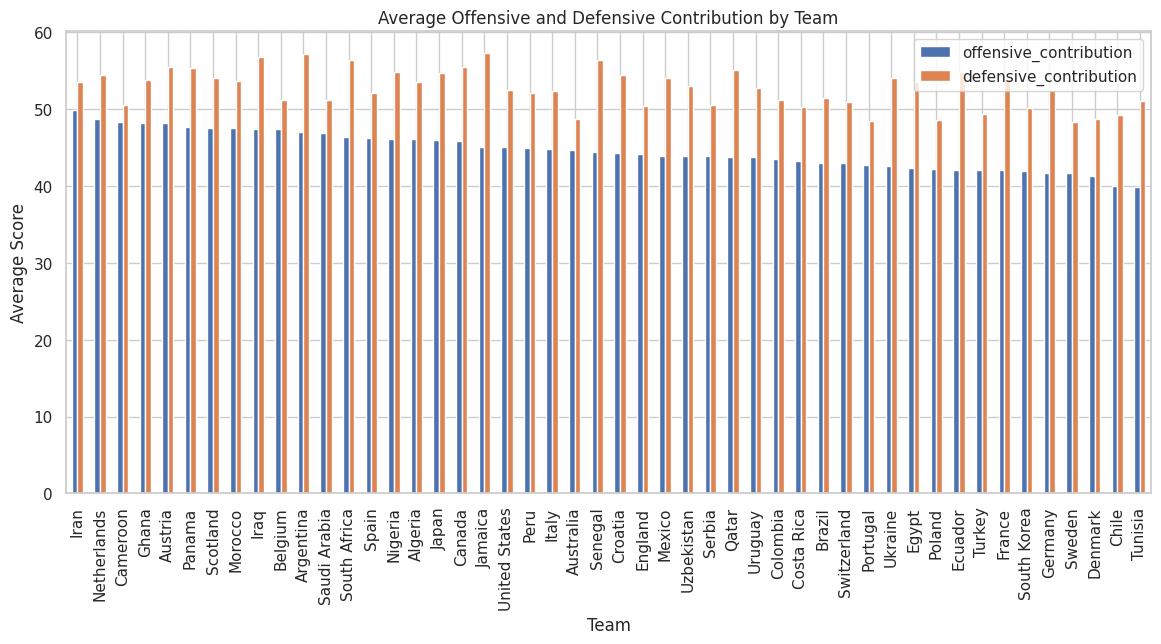

In [50]:
# ============================================================
# Offensive vs Defensive Contribution
# ============================================================

team_scores = (
    df.groupby("team")[
        ["offensive_contribution", "defensive_contribution"]
    ]
    .mean()
    .sort_values("offensive_contribution", ascending=False)
)

team_scores.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Average Offensive and Defensive Contribution by Team")
plt.xlabel("Team")
plt.ylabel("Average Score")

plt.xticks(rotation=90)

plt.show()

### Insights

- Compares each team's attacking and defensive strengths.
- Helps identify balanced teams as well as teams that rely more heavily on either offense or defense.
- Useful for understanding overall team playing style.

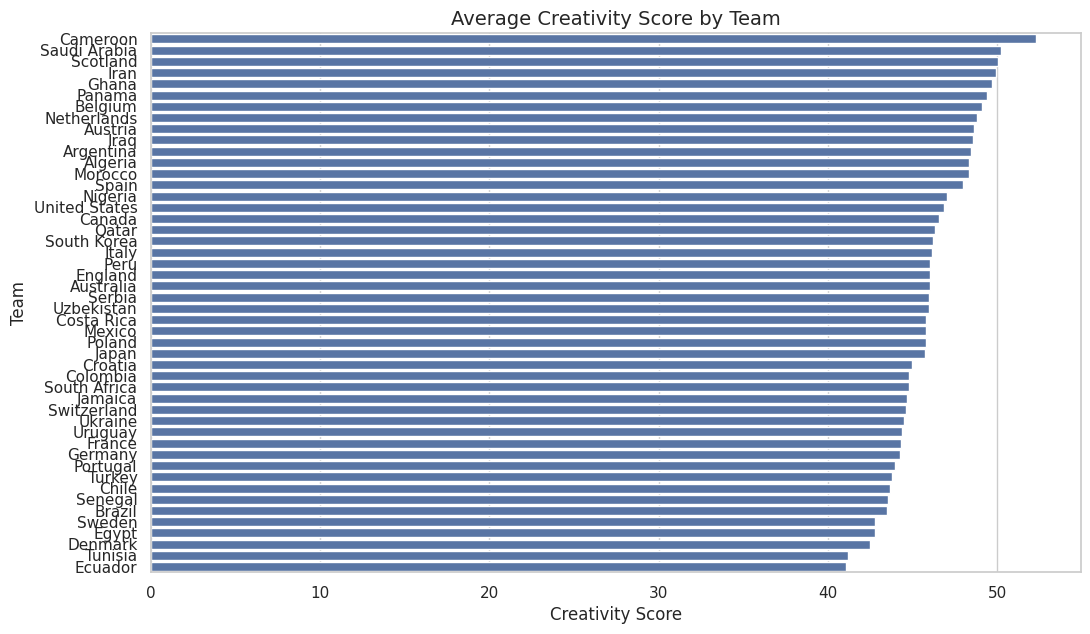

In [51]:
# ============================================================
# Team Creativity
# ============================================================

team_creativity = (
    df.groupby("team")["creativity_score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=team_creativity.values,
    y=team_creativity.index
)

plt.title("Average Creativity Score by Team", fontsize=14)
plt.xlabel("Creativity Score")
plt.ylabel("Team")

plt.show()

### Insights

- Compares the average creativity score across teams.
- Teams with higher scores are more effective at generating attacking opportunities.
- Creativity complements goal-scoring by measuring chance creation.

## Summary

The team analysis highlights differences in overall team quality and playing style.

### Key Findings

- Teams vary considerably in their overall performance scores and attacking output.
- Goal-scoring patterns reveal which teams are most effective in converting opportunities.
- Comparing offensive and defensive contributions provides insight into tactical balance.
- Creativity scores help identify teams that consistently create high-quality attacking chances.

Together, these metrics provide a comprehensive overview of team performance throughout the tournament.

# Correlation Analysis

Correlation analysis helps identify relationships between numerical variables and highlights which features move together.

Understanding these relationships is valuable for discovering patterns, identifying influential variables, and supporting future predictive modeling.

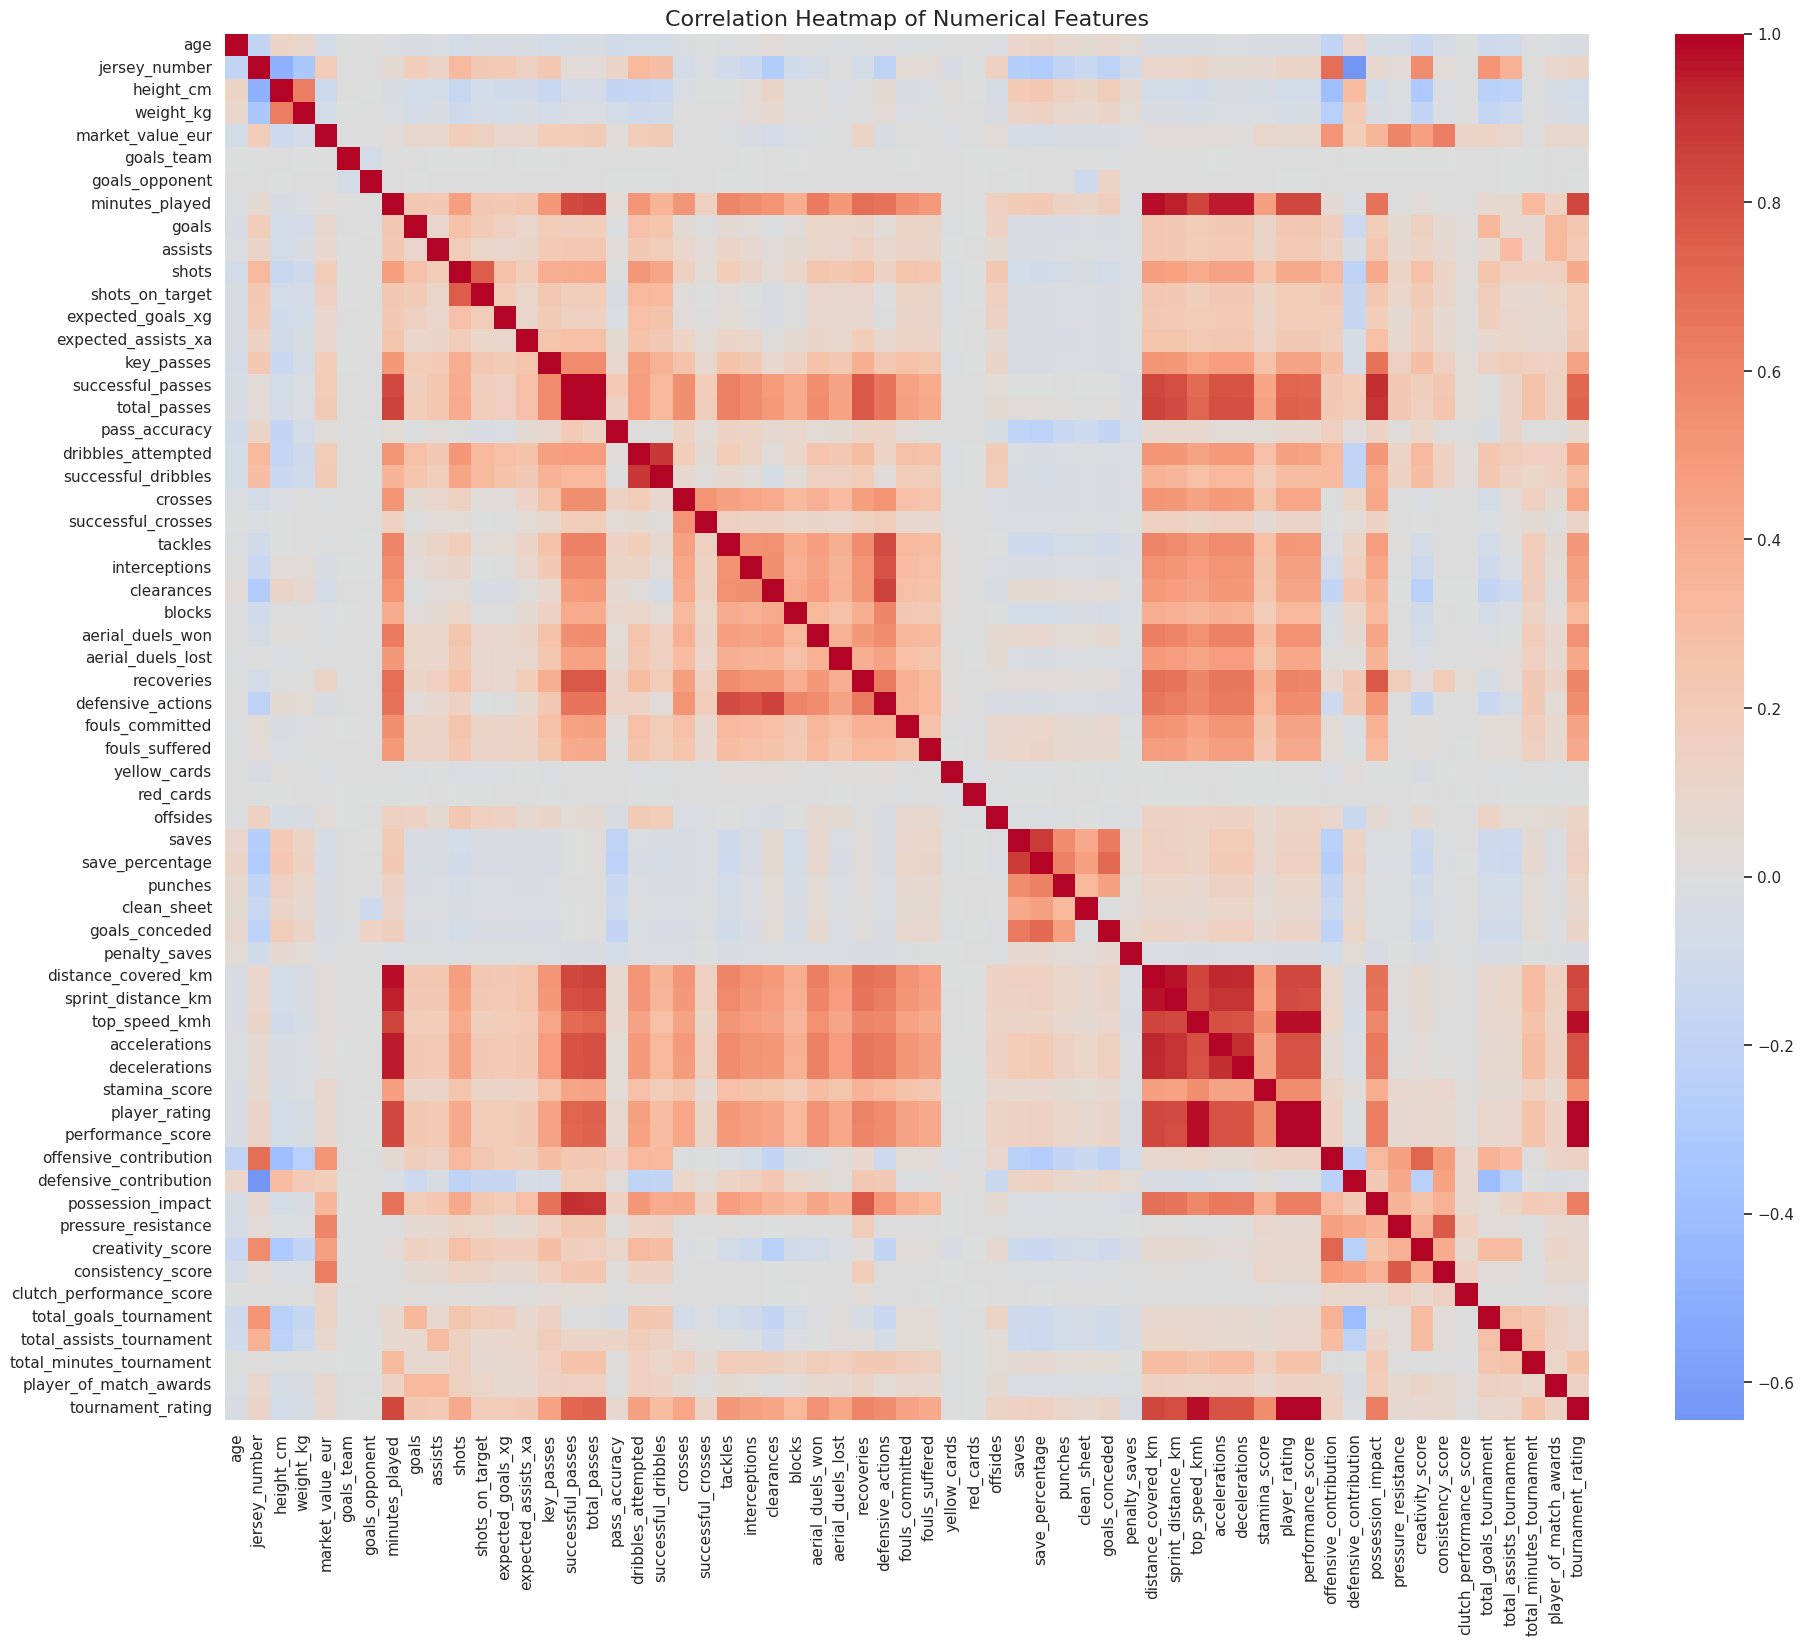

In [52]:
# ============================================================
# Correlation Analysis
# ============================================================

numerical_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(22,18))

sns.heatmap(
    numerical_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)

plt.show()

In [53]:
# ============================================================
# Strongest Feature Correlations
# ============================================================

corr_matrix = numerical_df.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

top_correlations = (
    upper_triangle.stack()
                  .sort_values(ascending=False)
                  .head(15)
                  .reset_index()
)

top_correlations.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

top_correlations

,Feature 1,Feature 2,Correlation
0,player_rating,tournament_rating,0.997337
1,player_rating,performance_score,0.996610
2,successful_passes,total_passes,0.994782
3,performance_score,tournament_rating,0.993943
4,top_speed_kmh,player_rating,0.979422
5,minutes_played,distance_covered_km,0.977282
6,top_speed_kmh,tournament_rating,0.976900
7,top_speed_kmh,performance_score,0.975388
8,distance_covered_km,sprint_distance_km,0.969201
9,minutes_played,accelerations,0.953944


## Summary

The correlation analysis reveals the strength of relationships between performance metrics.

### Key Findings

- Several offensive metrics exhibit strong positive relationships, indicating that they measure complementary aspects of attacking performance.
- Defensive variables also show meaningful associations, reflecting the interconnected nature of defensive actions.
- Overall performance scores are influenced by multiple offensive, defensive, and physical attributes rather than a single metric.

# Key Insights

The exploratory analysis produced several important observations regarding player and team performance.

## Major Findings

- The dataset is complete, containing no missing values or duplicate records.
- Player ages are concentrated within a relatively narrow range, indicating a balance between youth and experience.
- Right-footed players significantly outnumber left-footed players.
- Goal scoring is concentrated among a relatively small group of players.
- Creative players consistently contribute through assists and key passes in addition to scoring.
- High passing accuracy alone does not necessarily result in more goal-scoring opportunities.
- Defensive contribution varies considerably across playing positions.
- Performance scores differ across positions, reflecting distinct tactical responsibilities.
- Teams with higher creativity scores generally demonstrate stronger attacking output.
- Offensive and defensive contributions together provide a more balanced assessment of overall player quality.
- Correlation analysis highlights strong relationships among several attacking and defensive metrics.
- Overall player evaluation should consider technical, physical, and tactical attributes rather than relying on a single statistic.

# Business Recommendations

Based on the analysis, the following recommendations can support coaches, analysts, and recruitment teams.

## Recommendations

- Evaluate players using multiple performance metrics instead of focusing solely on goals or assists.
- Combine offensive, defensive, and creativity scores when identifying transfer targets.
- Use passing and creativity metrics to recognize playmakers who may be undervalued by traditional statistics.
- Monitor players with consistently high performance scores across multiple matches, as they demonstrate greater reliability.
- Tailor player evaluations according to positional responsibilities rather than using identical criteria for every role.
- Utilize defensive contribution metrics to recognize players whose impact may not be reflected through attacking statistics.
- Integrate advanced performance indicators into scouting reports to support evidence-based recruitment decisions.

# Conclusion

This project performed a comprehensive Exploratory Data Analysis (EDA) on a FIFA World Cup player performance dataset containing more than 54,000 player-match records and 75 performance-related features.

The analysis explored player demographics, match characteristics, offensive performance, passing quality, defensive actions, overall performance metrics, and team-level comparisons. Correlation analysis further highlighted important relationships among numerical variables.

Rather than relying on a single statistic, the findings demonstrate that player evaluation is most effective when offensive output, defensive contribution, creativity, and physical performance are considered together.

This project illustrates how data analytics can support modern football by providing objective insights for coaching, tactical planning, scouting, and recruitment decisions.

---

## Thank You

Thank you for exploring this analysis.

If you found this notebook helpful, consider giving it an **upvote**. Your support is greatly appreciated and encourages the creation of more high-quality data analytics projects.

Feedback and suggestions are always welcome.